In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, 
    roc_auc_score, 
    confusion_matrix, 
    classification_report
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# =====================================================================
# 1. Inicjalizacja i redukcja przestrzeni cech
# =====================================================================
df_train = pd.read_csv('online_shoppers_train_processed.csv')
df_test = pd.read_csv('online_shoppers_test_processed.csv')

X_train = df_train.drop(columns=['Revenue'])
y_train = df_train['Revenue']
X_test = df_test.drop(columns=['Revenue'])
y_test = df_test['Revenue']

# Eliminacja wektorów współliniowych (Pearson > 0.9)
corr_matrix = X_train.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
cols_to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]

X_train_reduced = X_train.drop(columns=cols_to_drop)
X_test_reduced = X_test.drop(columns=cols_to_drop)

# =====================================================================
# 2. Definicja estymatorów i procedury walidacyjnej 5x2 CV
# =====================================================================

log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

# Ograniczenie max_depth zapobiega przeuczeniu wariancji typowemu dla RF
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, class_weight='balanced', n_jobs=-1)

cv_strategy = RepeatedStratifiedKFold(n_splits=2, n_repeats=5, random_state=42)

scoring_metrics = ['roc_auc', 'precision', 'recall', 'f1', 'balanced_accuracy']

def evaluate_model_cv(estimator, name):
    cv_results = cross_validate(estimator, X_train_reduced, y_train, cv=cv_strategy, scoring=scoring_metrics)
    print(f"--- {name} ---")
    print(f"AUC:       {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std() * 2:.4f})")
    print(f"F1-Score:  {cv_results['test_f1'].mean():.4f} (+/- {cv_results['test_f1'].std() * 2:.4f})")
    print(f"Precision: {cv_results['test_precision'].mean():.4f} (+/- {cv_results['test_precision'].std() * 2:.4f})")
    print(f"Recall:    {cv_results['test_recall'].mean():.4f} (+/- {cv_results['test_recall'].std() * 2:.4f})")
    print(f"BAccuracy: {cv_results['test_balanced_accuracy'].mean():.4f} (+/- {cv_results['test_balanced_accuracy'].std() * 2:.4f})\n")

print("WYNIKI WALIDACJI KRZYŻOWEJ (5x2 CV):\n")
evaluate_model_cv(log_reg, "Regresja Logistyczna")
evaluate_model_cv(rf_clf, "Random Forest")

# =====================================================================
# 3. Estymacja parametrów na pełnym zbiorze treningowym
# =====================================================================
log_reg.fit(X_train_reduced, y_train)
y_pred_lr = log_reg.predict(X_test_reduced)
y_prob_lr = log_reg.predict_proba(X_test_reduced)[:, 1]

rf_clf.fit(X_train_reduced, y_train)
y_pred_rf = rf_clf.predict(X_test_reduced)
y_prob_rf = rf_clf.predict_proba(X_test_reduced)[:, 1]

# =====================================================================
# 4. Analiza dystrybucji błędów (Error Analysis) na zbiorze testowym
# =====================================================================
def print_error_analysis(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"Analiza subpopulacji macierzy pomyłek: {model_name}")
    print(f"True Positives (TP):  {tp}")
    print(f"True Negatives (TN):  {tn}")
    print(f"Błąd I rodzaju (FP):  {fp}")
    print(f"Błąd II rodzaju (FN): {fn}\n")

print("EWALUACJA ZDOLNOŚCI DYSKRYMINACYJNEJ (ZBIÓR TESTOWY):\n")
print(f"AUC (Regresja Logistyczna): {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"AUC (Random Forest):        {roc_auc_score(y_test, y_prob_rf):.4f}\n")

print_error_analysis(y_test, y_pred_lr, "Regresja Logistyczna")
print_error_analysis(y_test, y_pred_rf, "Random Forest")

WYNIKI WALIDACJI KRZYŻOWEJ (5x2 CV):

--- Regresja Logistyczna ---
AUC:       0.8947 (+/- 0.0103)
F1-Score:  0.6104 (+/- 0.0211)
Precision: 0.5182 (+/- 0.0224)
Recall:    0.7427 (+/- 0.0268)
BAccuracy: 0.8074 (+/- 0.0145)

--- Random Forest ---
AUC:       0.9207 (+/- 0.0080)
F1-Score:  0.6660 (+/- 0.0193)
Precision: 0.6248 (+/- 0.0176)
Recall:    0.7132 (+/- 0.0342)
BAccuracy: 0.8169 (+/- 0.0160)

EWALUACJA ZDOLNOŚCI DYSKRYMINACYJNEJ (ZBIÓR TESTOWY):

AUC (Regresja Logistyczna): 0.9049
AUC (Random Forest):        0.9265

Analiza subpopulacji macierzy pomyłek: Regresja Logistyczna
True Positives (TP):  297
True Negatives (TN):  1796
Błąd I rodzaju (FP):  263
Błąd II rodzaju (FN): 85

Analiza subpopulacji macierzy pomyłek: Random Forest
True Positives (TP):  291
True Negatives (TN):  1864
Błąd I rodzaju (FP):  195
Błąd II rodzaju (FN): 91



# Extra plots

NameError: name 'RocCurveDisplay' is not defined

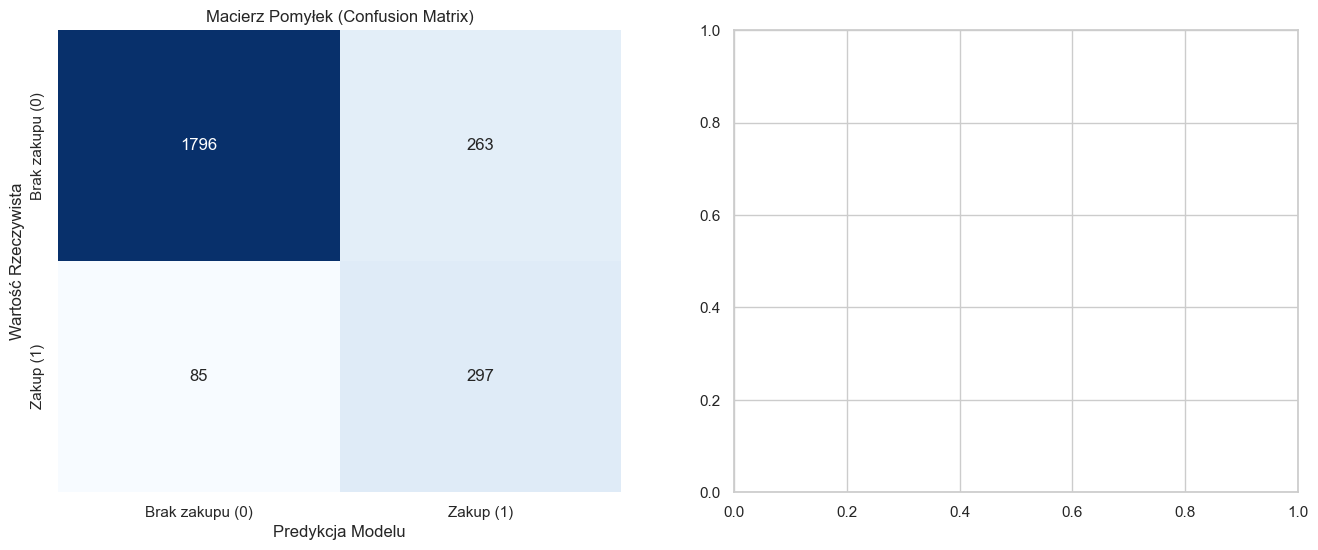

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Estymacja macierzy pomyłek (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1)
ax1.set_title('Macierz Pomyłek (Confusion Matrix)')
ax1.set_xlabel('Predykcja Modelu')
ax1.set_ylabel('Wartość Rzeczywista')
ax1.set_xticklabels(['Brak zakupu (0)', 'Zakup (1)'])
ax1.set_yticklabels(['Brak zakupu (0)', 'Zakup (1)'])

# Subplot 2: Estymacja krzywej ROC i parametru AUC
# Obliczenie wartości AUC do adnotacji na wykresie
auc_value = roc_auc_score(y_test, y_pred_proba)

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=ax2, color='darkorange', name='Regresja Logistyczna')
ax2.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Klasyfikator losowy')
ax2.set_title(f'Krzywa ROC (AUC = {auc_value:.4f})')
ax2.set_xlabel('Odsetek Fałszywie Pozytywnych (FPR)')
ax2.set_ylabel('Odsetek Prawdziwie Pozytywnych (TPR)')
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

C:\Users\janas\AppData\Local\Temp\ipykernel_3636\1888528596.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=11)


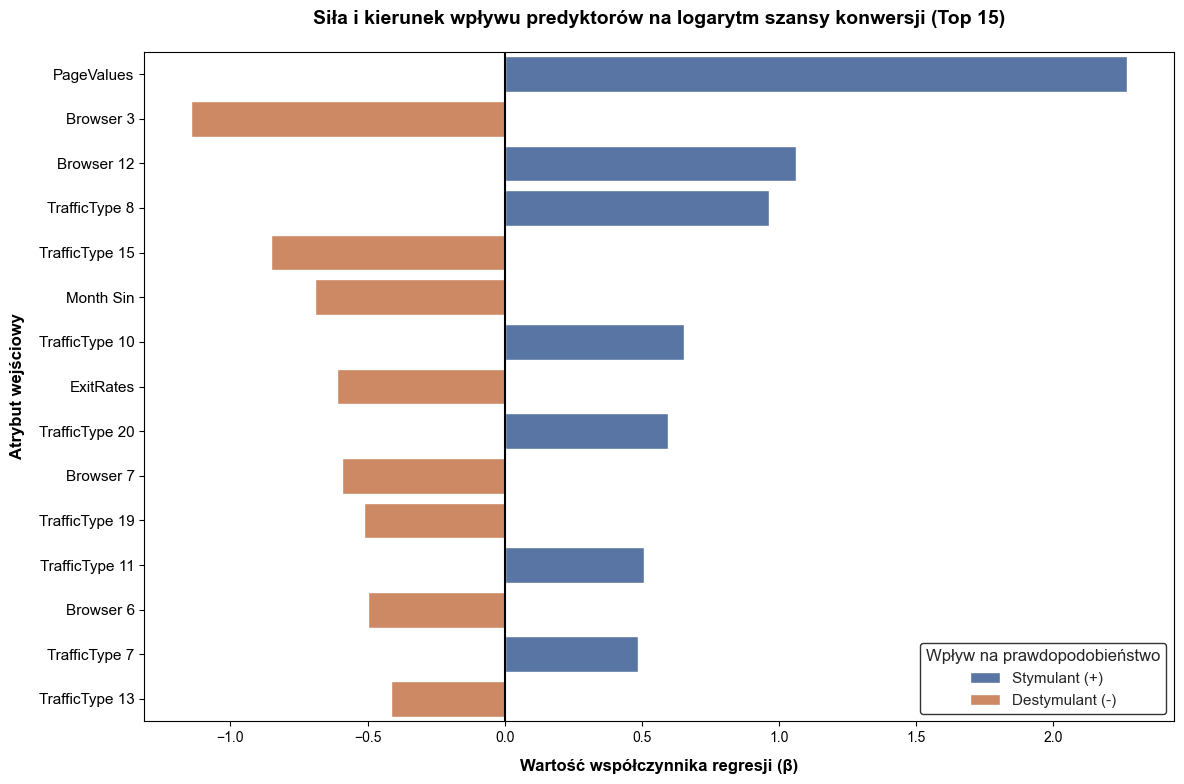

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

coef_data = pd.DataFrame({
    'Predyktor': X_train_reduced.columns,
    'Wspolczynnik': log_reg.coef_[0]
})

coef_data['Wplyw_Bezwzgledny'] = coef_data['Wspolczynnik'].abs()
coef_data = coef_data.sort_values(by='Wplyw_Bezwzgledny', ascending=False).head(15)

coef_data['Kierunek'] = np.where(coef_data['Wspolczynnik'] > 0, 'Stymulant (+)', 'Destymulant (-)')

fig, ax = plt.subplots(figsize=(12, 8))
sns.set_theme(style="whitegrid")

bar_plot = sns.barplot(
    x='Wspolczynnik', 
    y='Predyktor', 
    data=coef_data, 
    hue='Kierunek',
    palette={'Stymulant (+)': '#4C72B0', 'Destymulant (-)': '#DD8452'},
    dodge=False,
    ax=ax
)

ax.axvline(0, color='black', linewidth=1.5)
ax.set_title('Siła i kierunek wpływu predyktorów na logarytm szansy konwersji (Top 15)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Wartość współczynnika regresji (\u03B2)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Atrybut wejściowy', fontsize=12, fontweight='bold', labelpad=10)

labels = [item.get_text().replace('_', ' ') for item in ax.get_yticklabels()]
ax.set_yticklabels(labels, fontsize=11)

ax.legend(title='Wpływ na prawdopodobieństwo', loc='lower right', frameon=True, edgecolor='black', fontsize=11)

plt.tight_layout()
# Zapis na dysk
plt.savefig('feature_importance.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

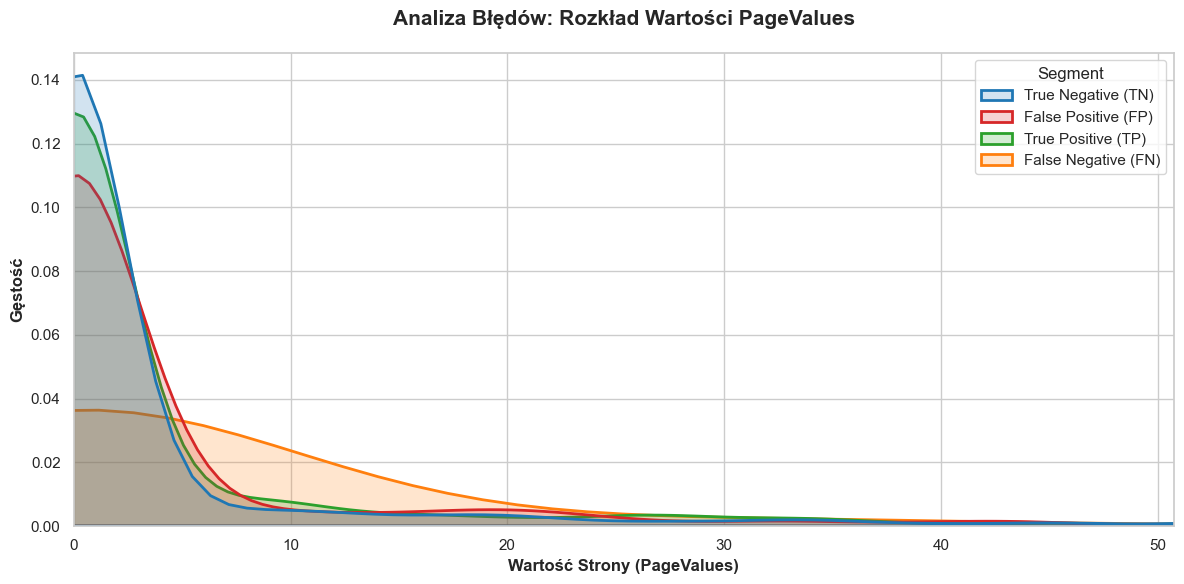

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('online_shoppers_intention.csv')

raw_page_values = df.loc[X_test.index, 'PageValues']

y_true_arr = np.array(y_test)
y_pred_arr = np.array(y_pred)

cond_tp = (y_true_arr == 1) & (y_pred_arr == 1)
cond_tn = (y_true_arr == 0) & (y_pred_arr == 0)
cond_fp = (y_true_arr == 0) & (y_pred_arr == 1)
cond_fn = (y_true_arr == 1) & (y_pred_arr == 0)

error_data = pd.DataFrame({
    'PageValues_Raw': raw_page_values.values,
    'Segment': np.select(
        [cond_tp, cond_tn, cond_fp, cond_fn],
        ['True Positive (TP)', 'True Negative (TN)', 'False Positive (FP)', 'False Negative (FN)'],
        default='Unknown'
    )
})

# 3. Wizualizacja KDE
fig, ax = plt.subplots(figsize=(12, 6))
sns.set_theme(style="whitegrid")

palette = {
    'True Positive (TP)': '#2ca02c', 
    'True Negative (TN)': '#1f77b4',
    'False Positive (FP)': '#d62728', 
    'False Negative (FN)': '#ff7f0e'
}

# common_norm=False jest KLUCZOWE - pozwala zobaczyć kształt rzadkich klas (FP, FN)
sns.kdeplot(
    data=error_data, 
    x='PageValues_Raw', 
    hue='Segment', 
    palette=palette, 
    fill=True, 
    alpha=0.2, 
    linewidth=2, 
    common_norm=False, 
    bw_adjust=0.8, # Mniejszy parametr bardziej uwydatnia detale rozkładu
    ax=ax
)

x_max_vis = error_data['PageValues_Raw'].quantile(0.98) # Odcinamy 2% skrajnych wartości
ax.set_xlim(0, x_max_vis) 

ax.set_title('Analiza Błędów: Rozkład Wartości PageValues', fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Wartość Strony (PageValues)', fontsize=12, fontweight='bold')
ax.set_ylabel('Gęstość', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('slide_17_raw_kde.png', dpi=300)
plt.show()